# **ZOMATO**

In [ ]:
!pip install requests beautifulsoup4 pandas lxml

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import json

headers = {
    "User-Agent": "Mozilla/5.0"
}

city_areas = {
    "bangalore": ["indiranagar", "whitefield", "koramangala", "btm", "marathahalli", "rs-city"],
    "chennai": ["t-nagar", "velachery", "adyar", "porur", "nungambakkam"],
    "hyderabad": ["jubilee-hills", "somajiguda", "ameerpet", "sr-nagar"],
    "mumbai": ["andheri", "bandra", "powai", "lower-parel", "chembur", "vashi", "thane"],
    "delhi": ["connaught-place", "karol-bagh", "saket", "rohini"],
    "kochi": ["kakkanad", "edappally", "fort-kochi"],
    "coimbatore": ["rs-puram", "gandhipuram", "peelamedu"],
    "mysore": ["vv-mohalla", "kuvempunagar", "jayalakshmipuram"],
    "kolkata": ["park-street", "salt-lake", "new-town", "dum-dum"],
    "ahmedabad": ["sg-highway", "navrangpura"],}


data = []

for city in city_areas:
    for area in city_areas[city]:
        for page in range(1, 4):

            url = f"https://www.zomato.com/{city}/{area}-restaurants?page={page}"
            print("Scraping:", city, area, "Page:", page)

            try:
                response = requests.get(url, headers=headers)
                soup = BeautifulSoup(response.text, "lxml")

                cards = soup.find_all("div", class_="jumbo-tracker")
                if not cards:
                    break

                scripts = soup.find_all("script", type="application/ld+json")
                json_data_list = []

                for script in scripts:
                    try:
                        json_data = json.loads(script.string)
                        json_data_list.append(json_data)
                    except:
                        continue

                for i, card in enumerate(cards):
                    try:
                        card_text = card.get_text().lower()

                        name_tag = card.find("h4")
                        name = name_tag.text.strip() if name_tag else None

                        price_tag = card.find(string=lambda text: text and "₹" in text)
                        price = price_tag.strip() if price_tag else None

                        cost_tag = card.find(string=lambda x: x and "for two" in x)
                        avg_cost_for_2 = cost_tag.strip() if cost_tag else None

                        link_tag = card.find("a", href=True)
                        link = "https://www.zomato.com" + link_tag["href"] if link_tag else None

                        cuisine_tag = card.find("p")
                        cuisine = cuisine_tag.get_text().strip() if cuisine_tag else None

                        rating_tag = card.find(string=lambda x: x and "." in x and len(x) < 5)
                        rating = rating_tag.strip() if rating_tag else None

                        has_online_delivery = 1 if "delivery" in card_text else 0

                        cost_number = float(''.join(filter(str.isdigit, avg_cost_for_2))) if avg_cost_for_2 else 0
                        has_table_booking = 1 if cost_number > 1500 else 0

                        try:
                            json_item = json_data_list[i]
                            if isinstance(json_item, dict):
                                has_online_delivery = json_item.get("hasOnlineDelivery", has_online_delivery)
                        except:
                            pass

                        data.append([
                            name, cuisine, price, rating,
                            city, area,
                            avg_cost_for_2, link,
                            has_online_delivery,
                            has_table_booking
                        ])

                    except:
                        continue

                time.sleep(2)

            except Exception as e:
                print("Error:", e)

df = pd.DataFrame(data, columns=[
    "Name", "Cuisine", "Price", "Rating",
    "City", "Area",
    "avg_cost_for_2", "Link",
    "hasOnlineDelivery",
    "hasTableBooking"
])

print("Before duplicates:", len(df))



df.to_csv("zomato_dataset_with_features.csv", index=False)

print("Dataset saved with new features1!")

Scraping: bangalore indiranagar Page: 1
Scraping: bangalore indiranagar Page: 2
Scraping: bangalore indiranagar Page: 3
Scraping: bangalore whitefield Page: 1
Scraping: bangalore whitefield Page: 2
Scraping: bangalore whitefield Page: 3
Scraping: bangalore koramangala Page: 1
Scraping: bangalore koramangala Page: 2
Scraping: bangalore koramangala Page: 3
Scraping: bangalore btm Page: 1
Scraping: bangalore btm Page: 2
Scraping: bangalore btm Page: 3
Scraping: bangalore marathahalli Page: 1
Scraping: bangalore marathahalli Page: 2
Scraping: bangalore marathahalli Page: 3
Scraping: bangalore rs-city Page: 1
Scraping: chennai t-nagar Page: 1
Scraping: chennai t-nagar Page: 2
Scraping: chennai t-nagar Page: 3
Scraping: chennai velachery Page: 1
Scraping: chennai velachery Page: 2
Scraping: chennai velachery Page: 3
Scraping: chennai adyar Page: 1
Scraping: chennai adyar Page: 2
Scraping: chennai adyar Page: 3
Scraping: chennai porur Page: 1
Scraping: chennai porur Page: 2
Scraping: chennai 

In [ ]:
#combined all dataset i got from scraping

In [ ]:
import pandas as pd


In [ ]:
df_zomato2=pd.read_csv('/content/zomato_dataset_with_features.csv')
df_zomato3=pd.read_csv('/content/zomato_dataset_with_features2.csv')
df_zomato4=pd.read_excel('/content/zomato_final_dataset_with_features.xlsx')
df_zomato5=pd.read_csv('/content/zomato_dataset_final (5).csv')
df_zomato6=pd.read_csv('/content/zomato_dataset_final (6).csv')
df_zomato7=pd.read_csv('/content/zomato_dataset_final (3).csv')
df_zomato_final = pd.concat([ df_zomato2, df_zomato3, df_zomato4,df_zomato5,df_zomato6,df_zomato7], ignore_index=True)


In [ ]:
df_zomato_final.shape

(13888, 19)

In [ ]:
df_zomato_final.duplicated().sum()

np.int64(6797)

In [ ]:
df_zomato_final.drop_duplicates(inplace=True)

In [ ]:
df_zomato_final.duplicated().sum()

np.int64(0)

In [ ]:
df_zomato_final.shape

(7091, 19)

In [ ]:
df_zomato_final.to_excel('/content/zomato_master_dataset.xlsx', index=False)
print("Combined dataset saved! Total rows:", len(df_zomato_final))

Combined dataset saved! Total rows: 7091


In [ ]:
df_zomato_final.head()

,Name,Cuisine,Price,Rating,City,Area,avg_cost_for_2,Link,hasOnlineDelivery,hasTableBooking,Unnamed: 0,Cost_for_2,Cost_Category,Success,Delivery,Online_Order,Reviews,Votes,table_booking
0,Vesparo,"Pasta, Continental, Asian, Thai, Momos","₹1,800 for two",4.3,bangalore,indiranagar,"₹1,800 for two",https://www.zomato.com/bangalore/vesparo-indir...,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Homiga,"Korean, Asian","₹2,000 for two",4.6,bangalore,indiranagar,"₹2,000 for two",https://www.zomato.com/bangalore/homiga-brigad...,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1BHK,"Continental, Italian, Pizza, Sandwich, Dessert...","₹2,500 for two",4.2,bangalore,indiranagar,"₹2,500 for two",https://www.zomato.com/bangalore/1bhk-koramang...,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Brik Oven - Woodfired Pizzas,"Pizza, Italian, Beverages, Desserts, Shake","₹1,200 for two",4.5,bangalore,indiranagar,"₹1,200 for two",https://www.zomato.com/bangalore/brik-oven-woo...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Idylll - Indian Plates & Cocktails,"North Indian, Modern Indian, South Indian, Sea...","₹2,600 for two",4.6,bangalore,indiranagar,"₹2,600 for two",https://www.zomato.com/bangalore/idylll-indian...,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_zomato_final.isnull().sum()

,0
Name,166
Cuisine,108
Price,166
Rating,398
City,0
Area,0
avg_cost_for_2,3136
Link,3040
hasOnlineDelivery,3348
hasTableBooking,3348


In [ ]:
#froping reapeted columns

In [ ]:
df_zomato_final.drop(columns=['Cost_for_2','Success','Delivery','Online_Order','Votes','table_booking'], inplace=True)

In [ ]:
df_zomato_final

,Unnamed: 0.1,Name,Cuisine,Price,Rating,City,Area,avg_cost_for_2,Link,hasOnlineDelivery,hasTableBooking,Cost_Category,Reviews
0,0,Vesparo,"Pasta, Continental, Asian, Thai, Momos","₹1,800 for two",4.3,bangalore,indiranagar,"₹1,800 for two",https://www.zomato.com/bangalore/vesparo-indir...,0.0,1.0,NaN,NaN
1,1,Homiga,"Korean, Asian","₹2,000 for two",4.6,bangalore,indiranagar,"₹2,000 for two",https://www.zomato.com/bangalore/homiga-brigad...,0.0,1.0,NaN,NaN
2,2,1BHK,"Continental, Italian, Pizza, Sandwich, Dessert...","₹2,500 for two",4.2,bangalore,indiranagar,"₹2,500 for two",https://www.zomato.com/bangalore/1bhk-koramang...,0.0,1.0,NaN,NaN
3,3,Brik Oven - Woodfired Pizzas,"Pizza, Italian, Beverages, Desserts, Shake","₹1,200 for two",4.5,bangalore,indiranagar,"₹1,200 for two",https://www.zomato.com/bangalore/brik-oven-woo...,0.0,0.0,NaN,NaN
4,4,Idylll - Indian Plates & Cocktails,"North Indian, Modern Indian, South Indian, Sea...","₹2,600 for two",4.6,bangalore,indiranagar,"₹2,600 for two",https://www.zomato.com/bangalore/idylll-indian...,0.0,1.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7086,7086,Classico Kitchen & Bar,"Fast Food, Chinese, Salad, Continental, Italia...","₹2,000 for two",4.8,pune,kothrud,"₹2,000 for two",NaN,NaN,NaN,NaN,4025.0
7087,7087,Gulp - Beer Garden,"Fast Food, Pasta, Pizza","₹2,100 for two",NaN,pune,kothrud,"₹2,100 for two",NaN,NaN,NaN,NaN,2969.0
7088,7088,Cibbo All Day Dining & Bar,"European, Pizza, Asian, Continental, Desserts","₹1,800 for two",4.3,pune,kothrud,"₹1,800 for two",NaN,NaN,NaN,NaN,1058.0
7089,7089,D Palace,"North Indian, Mughlai, Seafood, Chinese, Conti...","₹1,000 for two",4.1,pune,kothrud,"₹1,000 for two",NaN,NaN,NaN,NaN,1787.0


In [ ]:
df_zomato_final.to_excel('df_zomato.xlsx')

# **OPEN STREET MAP**

In [ ]:
import requests
import pandas as pd
import time

url = "https://overpass-api.de/api/interpreter"

cities = ["Kochi", "Bangalore", "Chennai", "Hyderabad", "Mumbai"]

all_data = []

for city in cities:
    print(f"Fetching {city}...")

    query = f"""
    [out:json][timeout:25];
    area["name"="{city}"]->.searchArea;
    (
      node["amenity"="restaurant"](area.searchArea);
      way["amenity"="restaurant"](area.searchArea);
      relation["amenity"="restaurant"](area.searchArea);
    );
    out center;
    """

    response = requests.post(url, data=query)

    if response.status_code != 200:
        print("Error:", city)
        continue

    data = response.json()

    for element in data.get("elements", []):
        name = element.get("tags", {}).get("name", "Unknown")
        lat = element.get("lat") or element.get("center", {}).get("lat")
        lon = element.get("lon") or element.get("center", {}).get("lon")
        cuisine = element.get("tags", {}).get("cuisine", "Unknown")

        all_data.append({
            "Name": name,
            "Cuisine": cuisine,
            "latitude": lat,
            "longitude": lon,
            "City": city
        })

    time.sleep(2)

df_osm = pd.DataFrame(all_data)



df_osm.to_csv("osm_all_cities.csv", index=False)
print("Saved!")

Fetching Kochi...
Fetching Bangalore...
Fetching Chennai...
Fetching Hyderabad...
Error: Hyderabad
Fetching Mumbai...
Error: Mumbai
Saved!


In [ ]:
df_osm

,Name,Cuisine,latitude,longitude,City
0,Bangalore,indian,41.149197,-73.245964,Bangalore
1,The Great Kabab Factory,Unknown,12.994682,80.187407,Chennai
2,Tangerine,Unknown,13.039255,80.255622,Chennai
3,Ente Keralam,Unknown,13.042114,80.255897,Chennai
4,Suriyas,Unknown,13.038319,80.256671,Chennai
...,...,...,...,...,...
2394,Sharma bhelpuri house,chaat,19.101769,72.846287,Mumbai
2395,Gallops,Unknown,18.981045,72.817215,Mumbai
2396,Gracias Granny,mexican,19.078662,72.837615,Mumbai
2397,Saroj,indian,19.053518,72.886200,Mumbai


In [ ]:
from sklearn.neighbors import BallTree
import numpy as np

print("calculating competition density (fast version)...")

# remove nulls
valid = df_osm[df_osm["latitude"].notna() & df_osm["longitude"].notna()].copy()

# convert to radians
coords = np.radians(valid[["latitude", "longitude"]].values)

# build tree
tree = BallTree(coords, metric='haversine')

# radius in radians (1 km)
radius = 1 / 6371

# query neighbors
counts = tree.query_radius(coords, r=radius, count_only=True)

# subtract self-count
valid["competition_density_1km"] = counts - 1

# merge back
df_osm = df_osm.merge(
    valid[["Name", "City", "competition_density_1km"]],
    on=["Name", "City"], how="left"
)


df_osm["competition_density_1km"] = df_osm["competition_density_1km"].fillna(0)

print("done!")
print(f"avg competitors within 1km: {df_osm['competition_density_1km'].mean():.1f}")

df_osm.to_csv("osm_restaurants_with_density.csv", index=False)
print("Saved successfully!")

calculating competition density (fast version)...
done!
avg competitors within 1km: 16.7
Saved successfully!


In [ ]:
df_osm

,Name,Cuisine,latitude,longitude,City
0,Bangalore,indian,41.149197,-73.245964,Bangalore
1,The Great Kabab Factory,Unknown,12.994682,80.187407,Chennai
2,Tangerine,Unknown,13.039255,80.255622,Chennai
3,Ente Keralam,Unknown,13.042114,80.255897,Chennai
4,Suriyas,Unknown,13.038319,80.256671,Chennai
...,...,...,...,...,...
2393,Juliette Café and Bar,Unknown,19.141601,72.830031,Mumbai
2394,Sharma bhelpuri house,chaat,19.101769,72.846287,Mumbai
2395,Gallops,Unknown,18.981045,72.817215,Mumbai
2397,Saroj,indian,19.053518,72.886200,Mumbai


In [ ]:
df_density

,Name,Cuisine,latitude,longitude,City,competition_density_1km
0,Bangalore,indian,41.149197,-73.245964,Bangalore,0
1,The Great Kabab Factory,Unknown,12.994682,80.187407,Chennai,2
2,Tangerine,Unknown,13.039255,80.255622,Chennai,36
3,Ente Keralam,Unknown,13.042114,80.255897,Chennai,31
4,Suriyas,Unknown,13.038319,80.256671,Chennai,32
...,...,...,...,...,...,...
30172,Juliette Café and Bar,Unknown,19.141601,72.830031,Mumbai,34
30173,Sharma bhelpuri house,chaat,19.101769,72.846287,Mumbai,9
30174,Gallops,Unknown,18.981045,72.817215,Mumbai,7
30177,Saroj,indian,19.053518,72.886200,Mumbai,2


In [ ]:
#
!pip install rapidfuzz pandas openpyxl

import pandas as pd
from rapidfuzz import process, fuzz
import numpy as np

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 84.4 MB/s eta 0:00:00


In [ ]:
df_zomato=pd.read_excel('/content/df_zomato.xlsx')
df_osm=pd.read_csv('/content/osm_all_cities.csv')
df_density=pd.read_csv('/content/osm_restaurants_with_density.csv')

In [ ]:
for df in [df_zomato, df_osm, df_density]:
    df['Name'] = df['Name'].str.strip().str.lower()
    df['City'] = df['City'].str.strip().str.lower()

In [ ]:
from rapidfuzz import process, fuzz
import numpy as np

def fuzzy_match(name, name_list, threshold=85):
    if not name_list:  # empty list → no match
        return np.nan
    result = process.extractOne(name, name_list, scorer=fuzz.token_sort_ratio)
    if result is None:  # no match found
        return np.nan
    match, score, _ = result
    if score >= threshold:
        return match
    else:
        return np.nan

In [ ]:
df_zomato['matched_osm_name'] = np.nan
cities = df_zomato['City'].unique()

for city in cities:
    zomato_city_mask = df_zomato['City'] == city
    osm_city_names = df_osm[df_osm['City'] == city]['Name'].tolist()

    df_zomato.loc[zomato_city_mask, 'matched_osm_name'] = df_zomato.loc[zomato_city_mask, 'Name'].apply(
        lambda x: fuzzy_match(x, osm_city_names)
    )

/tmp/ipykernel_2579/1358228174.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[nan 'house of mandarin' nan nan nan nan 'butterfly high' 'gurukripa' nan
 nan nan nan nan nan nan 'goa portuguesa' nan nan 'cincin' 'yauatcha'
 'sante spa cuisine' nan nan 'pizzaexpress' nan nan nan nan nan nan nan
 nan nan nan 'vadhavi resturant' nan 'butterfly high' nan nan nan nan nan
 nan 'pizzaexpress' nan 'the sassy spoon' nan nan nan nan nan nan nan nan
 nan nan nan nan nan 'hitchki' nan 'mahesh lunch home' nan nan nan nan nan
 nan nan nan nan 'house of mandarin' 'the sassy spoon' nan nan nan
 'origami japanese and korean restaurant' nan nan nan 'house of mandarin'
 'the sassy spoon' nan nan nan 'origami japanese and korean restaurant'
 nan nan nan 'house of mandarin' 'the sassy spoon' nan nan nan
 'origami japanese and korean restaurant' nan nan nan 'house of mandarin'
 'the sassy spoon' nan nan nan 'origami japan

In [ ]:
# Rename OSM 'Name' column to match fuzzy matched column
df_osm_renamed = df_osm[['Name','City','latitude','longitude']].rename(columns={'Name':'matched_osm_name'})

# Merge Zomato with OSM
df_combined = pd.merge(
    df_zomato,
    df_osm_renamed,
    on=['matched_osm_name','City'],
    how='left'
)

In [ ]:
# Rename density 'Name' column
df_density_renamed = df_density[['Name','City','competition_density_1km']].rename(columns={'Name':'matched_osm_name'})

# Merge density
df_combined = pd.merge(
    df_combined,
    df_density_renamed,
    on=['matched_osm_name','City'],
    how='left'
)

In [ ]:


# Save final combined dataset
df_combined.to_excel('/content/restaurant_dataset_final.xlsx', index=False)

print("Final dataset ready! Total rows:", len(df_combined))
print("Null values per column:")
print(df_combined.isnull().sum())

Final dataset ready! Total rows: 7138
Null values per column:
Unnamed: 0.1                  0
Name                        166
Cuisine                     108
Price                       166
Rating                      398
City                          0
Area                          0
avg_cost_for_2             3164
Link                       3044
hasOnlineDelivery          3356
hasTableBooking            3356
Unnamed: 0                 3995
Cost_Category              3995
Reviews                    4546
matched_osm_name           6989
latitude                   6989
longitude                  6989
competition_density_1km    7138
dtype: int64


Fuzzy matching was used to align restaurant names between Zomato and OSM datasets because the names are not always identical. There may be small differences in spelling, punctuation, or word order.allows us to find the closest match automatically, ensuring we can combine features like latitude, longitude, and competition density accurately for each restaurant.

In [ ]:
df_combined.isnull().sum()

,0
Unnamed: 0.1,0
Name,166
Cuisine,108
Price,166
Rating,398
City,0
Area,0
avg_cost_for_2,3164
Link,3044
hasOnlineDelivery,3356


In [ ]:
df_combined['latitude'].isnull().sum()

np.int64(6989)

In [ ]:
df_combined.shape

(7138, 18)

In [ ]:
df_combined = df_combined.drop(columns=['Unnamed: 0.1'], errors='ignore')

In [ ]:
df_combined.isnull().sum()

,0
Unnamed: 0,0
Name,166
Cuisine,108
Price,166
Rating,398
City,0
Area,0
avg_cost_for_2,3626
Link,3110
hasOnlineDelivery,3488


In [ ]:
# Save the dataset, showing NaNs explicitly in Excel
df_combined.to_excel(
    '/content/restaurant_dataset_final.xlsx',
    index=False,
    na_rep='NaN'  # This tells Excel to display NaN instead of leaving the cell blank
)

In [ ]:
df_combined

,Name,Cuisine,Price,Rating,City,Area,avg_cost_for_2,Link,hasOnlineDelivery,hasTableBooking,Unnamed: 0,Cost_Category,Reviews,matched_osm_name,latitude,longitude,competition_density_1km
0,vesparo,"Pasta, Continental, Asian, Thai, Momos","₹1,800 for two",4.3,bangalore,indiranagar,"₹1,800 for two",https://www.zomato.com/bangalore/vesparo-indir...,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,homiga,"Korean, Asian","₹2,000 for two",4.6,bangalore,indiranagar,"₹2,000 for two",https://www.zomato.com/bangalore/homiga-brigad...,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1bhk,"Continental, Italian, Pizza, Sandwich, Dessert...","₹2,500 for two",4.2,bangalore,indiranagar,"₹2,500 for two",https://www.zomato.com/bangalore/1bhk-koramang...,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,brik oven - woodfired pizzas,"Pizza, Italian, Beverages, Desserts, Shake","₹1,200 for two",4.5,bangalore,indiranagar,"₹1,200 for two",https://www.zomato.com/bangalore/brik-oven-woo...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,idylll - indian plates & cocktails,"North Indian, Modern Indian, South Indian, Sea...","₹2,600 for two",4.6,bangalore,indiranagar,"₹2,600 for two",https://www.zomato.com/bangalore/idylll-indian...,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7133,classico kitchen & bar,"Fast Food, Chinese, Salad, Continental, Italia...","₹2,000 for two",4.8,pune,kothrud,"₹2,000 for two",NaN,NaN,NaN,NaN,NaN,4025.0,NaN,NaN,NaN,NaN
7134,gulp - beer garden,"Fast Food, Pasta, Pizza","₹2,100 for two",NaN,pune,kothrud,"₹2,100 for two",NaN,NaN,NaN,NaN,NaN,2969.0,NaN,NaN,NaN,NaN
7135,cibbo all day dining & bar,"European, Pizza, Asian, Continental, Desserts","₹1,800 for two",4.3,pune,kothrud,"₹1,800 for two",NaN,NaN,NaN,NaN,NaN,1058.0,NaN,NaN,NaN,NaN
7136,d palace,"North Indian, Mughlai, Seafood, Chinese, Conti...","₹1,000 for two",4.1,pune,kothrud,"₹1,000 for two",NaN,NaN,NaN,NaN,NaN,1787.0,NaN,NaN,NaN,NaN


I included latitude, longitude, and competition density features from OSM. However, due to partial matching, some values are missing. Ive retained them for analysis and will evaluate their usefulness during EDA before deciding whether to include them in the model.”

## **Understanding data**

In [ ]:
import pandas as pd
df_combined=pd.read_excel('/content/restaurant_dataset_final (2).xlsx')

In [ ]:
df_combined

,Unnamed: 0.1,Name,Cuisine,Price,Rating,City,Area,avg_cost_for_2,Link,hasOnlineDelivery,hasTableBooking,Unnamed: 0,Cost_Category,Reviews,matched_osm_name,latitude,longitude,competition_density_1km
0,0,vesparo,"Pasta, Continental, Asian, Thai, Momos","₹1,800 for two",4.3,bangalore,indiranagar,"₹1,800 for two",https://www.zomato.com/bangalore/vesparo-indir...,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,homiga,"Korean, Asian","₹2,000 for two",4.6,bangalore,indiranagar,"₹2,000 for two",https://www.zomato.com/bangalore/homiga-brigad...,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,1bhk,"Continental, Italian, Pizza, Sandwich, Dessert...","₹2,500 for two",4.2,bangalore,indiranagar,"₹2,500 for two",https://www.zomato.com/bangalore/1bhk-koramang...,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,brik oven - woodfired pizzas,"Pizza, Italian, Beverages, Desserts, Shake","₹1,200 for two",4.5,bangalore,indiranagar,"₹1,200 for two",https://www.zomato.com/bangalore/brik-oven-woo...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,idylll - indian plates & cocktails,"North Indian, Modern Indian, South Indian, Sea...","₹2,600 for two",4.6,bangalore,indiranagar,"₹2,600 for two",https://www.zomato.com/bangalore/idylll-indian...,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7133,13883,classico kitchen & bar,"Fast Food, Chinese, Salad, Continental, Italia...","₹2,000 for two",4.8,pune,kothrud,"₹2,000 for two",NaN,NaN,NaN,NaN,NaN,4025.0,NaN,NaN,NaN,NaN
7134,13884,gulp - beer garden,"Fast Food, Pasta, Pizza","₹2,100 for two",NaN,pune,kothrud,"₹2,100 for two",NaN,NaN,NaN,NaN,NaN,2969.0,NaN,NaN,NaN,NaN
7135,13885,cibbo all day dining & bar,"European, Pizza, Asian, Continental, Desserts","₹1,800 for two",4.3,pune,kothrud,"₹1,800 for two",NaN,NaN,NaN,NaN,NaN,1058.0,NaN,NaN,NaN,NaN
7136,13886,d palace,"North Indian, Mughlai, Seafood, Chinese, Conti...","₹1,000 for two",4.1,pune,kothrud,"₹1,000 for two",NaN,NaN,NaN,NaN,NaN,1787.0,NaN,NaN,NaN,NaN


In [ ]:
df_combined.shape

(7138, 17)

In [ ]:
df_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7138 entries, 0 to 7137
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0.1             7138 non-null   int64  
 1   Name                     6972 non-null   object 
 2   Cuisine                  7030 non-null   object 
 3   Price                    6972 non-null   object 
 4   Rating                   6740 non-null   float64
 5   City                     7138 non-null   object 
 6   Area                     7138 non-null   object 
 7   avg_cost_for_2           3974 non-null   object 
 8   Link                     4094 non-null   object 
 9   hasOnlineDelivery        3782 non-null   float64
 10  hasTableBooking          3782 non-null   float64
 11  Unnamed: 0               3143 non-null   float64
 12  Cost_Category            3143 non-null   object 
 13  Reviews                  2592 non-null   float64
 14  latitude                

In [ ]:
df_combined.dtypes

,0
Unnamed: 0.1,int64
Name,object
Cuisine,object
Price,object
Rating,float64
City,object
Area,object
avg_cost_for_2,object
Link,object
hasOnlineDelivery,float64


Latitude and longitude are raw spatial features that do not directly convey business insights. Therefore, they were transformed into a more meaningful feature, competition density, which captures the level of nearby competition. Additionally, missing values in coordinate data limited their direct use in analysis.

In [ ]:
df_combined.describe()

,Unnamed: 0,Rating,hasOnlineDelivery,hasTableBooking,Reviews,latitude,longitude,competition_density_1km
count,7931.000000,7533.000000,4443.000000,4443.000000,7931.000000,998.000000,998.000000,998.000000
mean,3965.000000,4.319222,0.003376,0.558181,826.590594,18.955167,73.202907,25.407816
std,2289.626825,0.310815,0.058013,0.496659,1440.846523,0.440148,1.358873,17.957015
min,0.000000,2.800000,0.000000,0.000000,0.000000,13.045142,72.815579,5.000000
25%,1982.500000,4.200000,0.000000,0.000000,0.000000,18.934027,72.826675,13.000000
50%,3965.000000,4.400000,0.000000,1.000000,0.000000,19.103666,72.833607,17.000000
75%,5947.500000,4.500000,0.000000,1.000000,1186.000000,19.103682,72.884323,34.000000
max,7930.000000,4.900000,1.000000,1.000000,5000.000000,19.141600,80.259255,71.000000


In [ ]:
df_combined.isnull().sum()

,0
Unnamed: 0.1,0
Name,166
Cuisine,108
Price,166
Rating,398
City,0
Area,0
avg_cost_for_2,3164
Link,3044
hasOnlineDelivery,3356


In [ ]:
df_combined.duplicated().sum()

np.int64(0)

##**Univariate Analysis**

###Rating Distribution

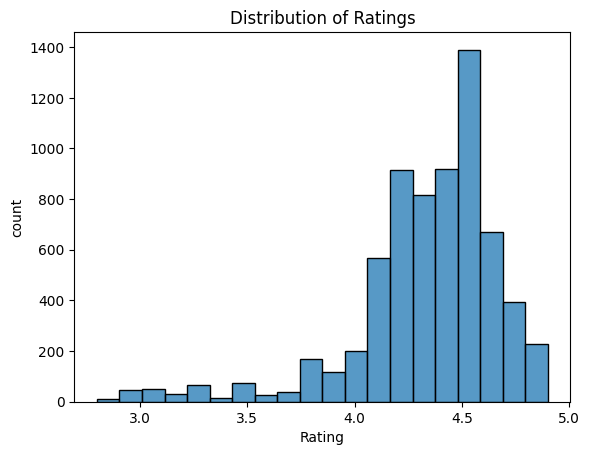

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.histplot(df_combined['Rating'],bins=20)
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('count')
plt.show()

Most restaurants have ratings between 4.0 and 4.6, with a peak around 4.3 to 4.5, indicating that a large number of restaurants are rated highly. The distribution is slightly left-skewed, meaning there are fewer low-rated restaurants compared to high-rated ones.few restaurants have ratings below 3.5, which suggests that poorly rated restaurants are less common in the dataset.dataset is dominated by well-rated restaurants, indicating generally good customer satisfaction.

###Price Distribution

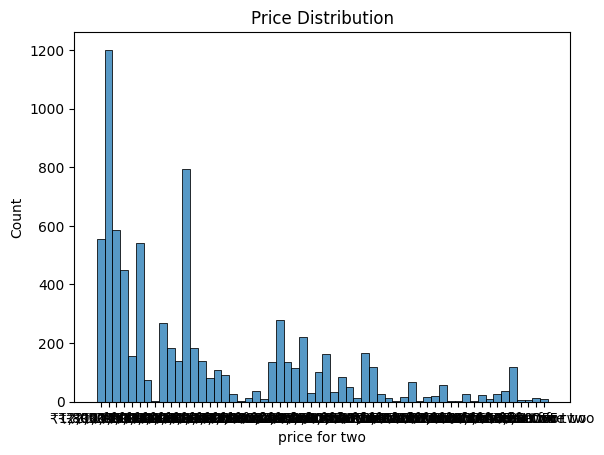

In [ ]:
plt.figure()
sns.histplot(df_combined['Price'], bins=20)
plt.title('Price Distribution')
plt.xlabel('price for two')
plt.show()

The graph shows that the vast majority of restaurants are clustered at the very low end of the price scale, creating a massive budget mountain where most people eat but competition is incredibly fierce.

###Top Cuisines

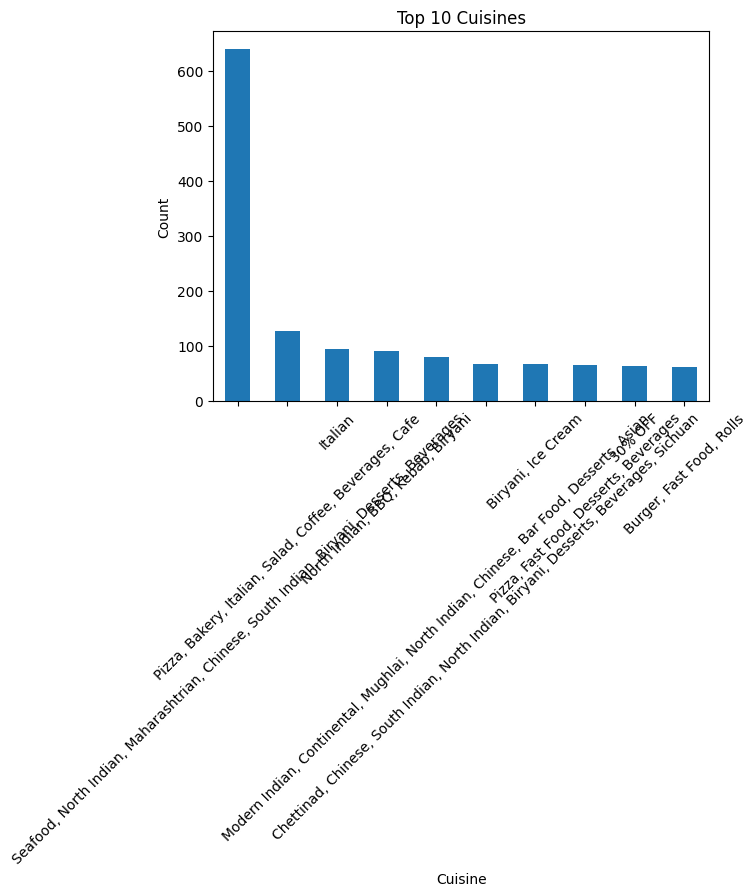

In [ ]:
df_combined["Cuisine"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Cuisines")
plt.xlabel('Cuisine')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

This graph shows that one specific cuisine is a massive "superstar" that dominates the market, with more than triple the count of any other category. For a restaurant owner, this means there is an incredibly high demand for that top item, but it also warns  that the market is already flooded with competitors selling the exact same thing.

### **Reviews Distribution**

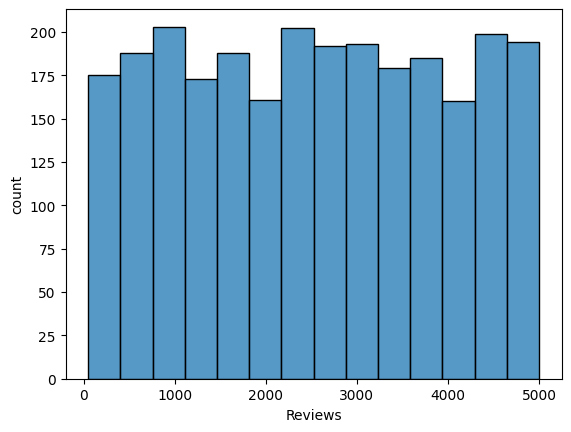

In [ ]:
plt.figure()
sns.histplot(df_combined['Reviews'])
plt.xlabel('Reviews')
plt.ylabel('count')
plt.show()

The graph shows that almost all restaurants have very few reviews, while only a tiny handful have managed to get thousands of customers talking. For a new restaurant, this means getting those first few dozen reviews is the hardest part

###City wise Distribution

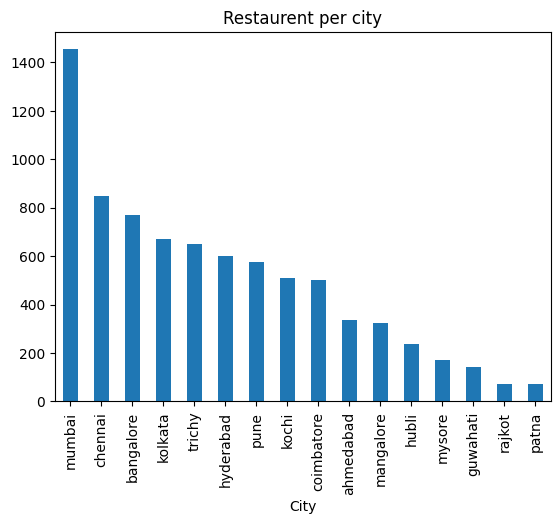

In [ ]:
plt.figure()
df_combined['City'].value_counts().plot(kind='bar')
plt.title('Restaurent per city')
plt.show()

means that while a city like Mumbai has the biggest "pie" and the most hungry customers, you are also entering the most competitive battlefield in the country.

Shows high competition zones
Very useful real-world insight

##**Bivariate Analysis**

###**Reviews vs Rating**

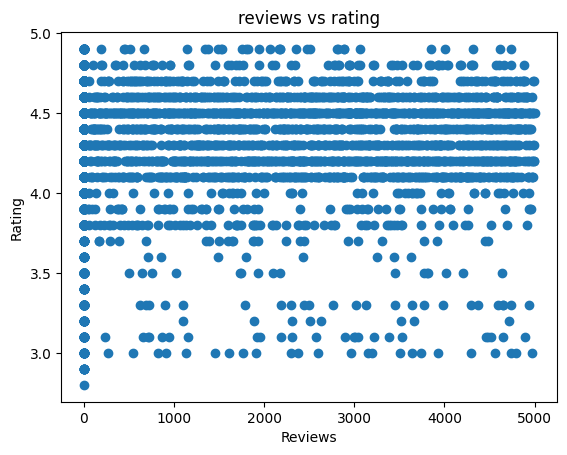

In [ ]:
plt.scatter(df_combined['Reviews'],df_combined['Rating'])
plt.xlabel('Reviews')
plt.ylabel('Rating')
plt.title('reviews vs rating')
plt.show()

his means that "popular" and "good" go hand in hand; if you can survive long enough to get thousands of reviews, you've likely found a formula that people consistently enjoy

### **Cost vs Rating**

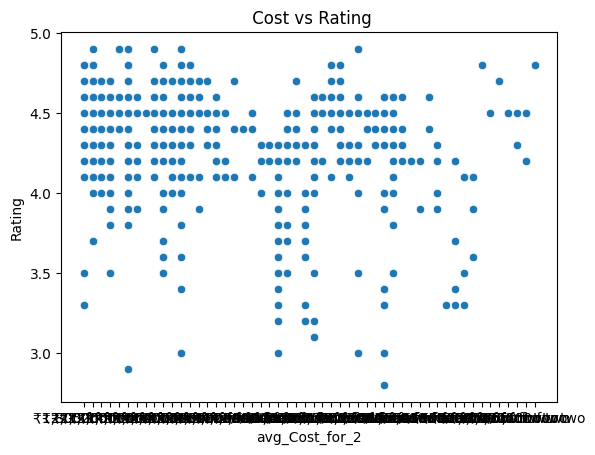

In [ ]:
plt.figure()
sns.scatterplot(x=df_combined['avg_cost_for_2'],y=df_combined['Rating'])
plt.xlabel('avg_Cost_for_2')
plt.ylabel('Rating')
plt.title(' Cost vs Rating')

plt.show()

shows that you don't need to be an expensive restaurant to have a 5-star rating, as there are plenty of top-rated spots even at the lowest price points.

In [ ]:
#Higher price does not always guarantee higher ratings.

###**Online delivery vs Rating**

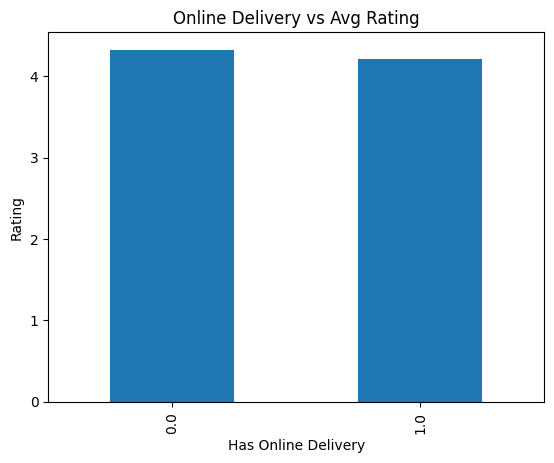

In [ ]:
df_combined.groupby('hasOnlineDelivery')['Rating'].mean().plot(kind='bar')
plt.title("Online Delivery vs Avg Rating")
plt.xlabel("Has Online Delivery")
plt.ylabel("Rating")
plt.show()

while delivery is great for reaching more customers, it won't magically make your food "better" in the eyes of the public. Real success comes from the quality of the service and food itself, regardless of whether its eaten at a table or out of a cardboard box.

###**Table Booking vs Rating**

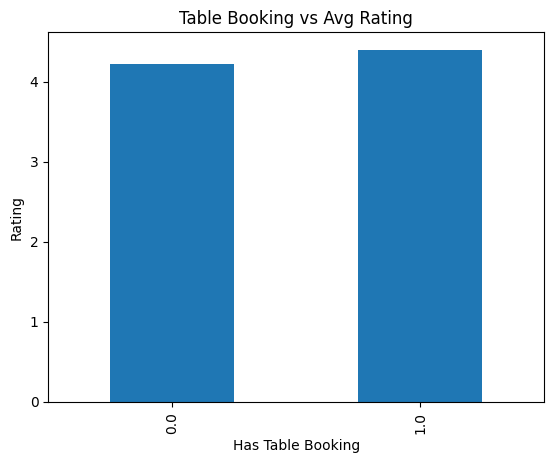

In [ ]:
df_combined.groupby('hasTableBooking')['Rating'].mean().plot(kind='bar')
plt.title("Table Booking vs Avg Rating")
plt.xlabel("Has Table Booking")
plt.ylabel("Rating")
plt.show()

this suggests that the convenience of booking a table creates a better first impression and a more organized dining experience, leading to happier customers

###**Competition Density vs Rating**

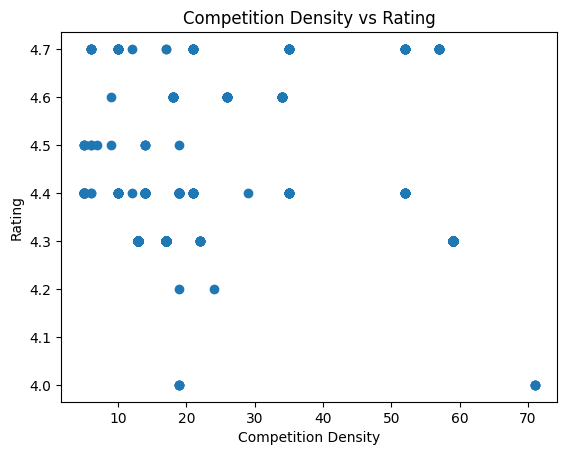

In [ ]:
plt.scatter(df_combined['competition_density_1km'], df_combined['Rating'])
plt.xlabel("Competition Density")
plt.ylabel("Rating")
plt.title("Competition Density vs Rating")
plt.show()

shows that being in a crowded area with lots of other restaurants doesn't automatically kill your rating; in fact, there are highly-rated spots even in areas with very high competition density.

# **DATA ENGINEERING**

In [1]:
import pandas as pd
df_combined=pd.read_csv('/content/resturent_data.csv')

In [2]:
df_combined.head(2)

,Unnamed: 0,Name,Cuisine,Price,Rating,City,Area,hasOnlineDelivery,hasTableBooking,Cost_Category,Reviews,matched_osm_name,latitude,longitude,competition_density_1km
0,0,vesparo,"Pasta, Continental, Asian, Thai, Momos",1800.0,4.3,bangalore,indiranagar,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN
1,1,homiga,"Korean, Asian",2000.0,4.6,bangalore,indiranagar,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df_combined['Price'] = (
    df_combined['Price']
    .astype(str)
    .str.extract(r'(\d[\d,]*)')[0]
    .str.replace(',', '', regex=False)
    .astype(float)
)

avg cost for 2 and cost 2 and price are representing the same thing .so im droiping avg cost for2,cost2



columns to drop=
- link
- avg cost for 2 two
- cost for 2 two
- matched_osm_name
- lattitude
- longitude

In [4]:
cols_to_drop = [
    'Unnamed: 0',
    'Unnamed: 0.1',
    'avg_cost_for_2',
    'Link',
    'matched_osm_name',
    'Name',
    'latitude',
    'longitude',
    'competition_density_1km' ]

df_new = df_combined.drop(columns=cols_to_drop, errors='ignore')



In [5]:
df_new.duplicated().sum()

np.int64(20)

In [6]:
df_new.drop_duplicates(inplace=True)

In [7]:
df_new.duplicated().sum()

np.int64(0)

In [8]:
#remove invalid rating rows
print(f"Rows before: {len(df_new)}")
print(f"Rating == 0: {(df_new['Rating'] == 0).sum()}")
print(f"Rating NaN: {df_new['Rating'].isna().sum()}")

df_new = df_new[
    (df_new['Rating'] >= 1.0) &
    (df_new['Rating'] <= 5.0)
].copy()
df_new.reset_index(drop=True, inplace=True)

print(f"Rows after:  {len(df_new)}")

Rows before: 4062
Rating == 0: 0
Rating NaN: 174
Rows after:  3888


In [9]:
#Rajkot (18), Patna (18), Guwahati (36), Hubli (43) are too small for the model to learn from. Group them as "Other".
print('City counts:')
print(df_new['City'].value_counts())

city_counts  = df_new['City'].value_counts()
small_cities = city_counts[city_counts < 50].index.tolist()
print(f"\nGrouping into 'Other': {small_cities}")

df_new['City'] = df_new['City'].replace(small_cities, 'Other')

print('\nFinal city counts:')
print(df_new['City'].value_counts())

City counts:
City
chennai       539
bangalore     431
kolkata       420
trichy        389
hyderabad     333
coimbatore    314
pune          305
mumbai        304
kochi         299
ahmedabad     210
mangalore     154
mysore        107
guwahati       34
patna          18
hubli          17
rajkot         14
Name: count, dtype: int64

Grouping into 'Other': ['guwahati', 'patna', 'hubli', 'rajkot']

Final city counts:
City
chennai       539
bangalore     431
kolkata       420
trichy        389
hyderabad     333
coimbatore    314
pune          305
mumbai        304
kochi         299
ahmedabad     210
mangalore     154
mysore        107
Other          83
Name: count, dtype: int64


In [10]:
#replaces competition_density. "How many restaurants are in this city?" is a clean, honest competition signal — Chennai (539) vs Rajkot (18) tells the model a lot.
# Map each restaurant to how many total restaurants its city has
city_count_map = df_new['City'].value_counts()
df_new['city_restaurant_count'] = df_new['City'].map(city_count_map)

print('city_restaurant_count sample:')
print(df_new[['City', 'city_restaurant_count']].drop_duplicates().sort_values(
    'city_restaurant_count', ascending=False
))

city_restaurant_count sample:
           City  city_restaurant_count
45      chennai                    539
0     bangalore                    431
232     kolkata                    420
476      trichy                    389
90    hyderabad                    333
196  coimbatore                    314
517        pune                    305
126      mumbai                    304
171       kochi                    299
268   ahmedabad                    210
505   mangalore                    154
223      mysore                    107
551       Other                     83


In [ ]:
df_new

,Cuisine,Price,Rating,City,Area,hasOnlineDelivery,hasTableBooking,Cost_Category,Reviews,city_restaurant_count
0,"Pasta, Continental, Asian, Thai, Momos",1800.0,4.3,bangalore,indiranagar,0.0,1.0,NaN,NaN,431
1,"Korean, Asian",2000.0,4.6,bangalore,indiranagar,0.0,1.0,NaN,NaN,431
2,"Continental, Italian, Pizza, Sandwich, Dessert...",2500.0,4.2,bangalore,indiranagar,0.0,1.0,NaN,NaN,431
3,"Pizza, Italian, Beverages, Desserts, Shake",1200.0,4.5,bangalore,indiranagar,0.0,0.0,NaN,NaN,431
4,"North Indian, Modern Indian, South Indian, Sea...",2600.0,4.6,bangalore,indiranagar,0.0,1.0,NaN,NaN,431
...,...,...,...,...,...,...,...,...,...,...
3883,"Continental, Modern Indian, Asian, Oriental",1000.0,4.4,pune,kothrud,NaN,NaN,NaN,1535.0,305
3884,"Fast Food, Chinese, Salad, Continental, Italia...",2000.0,4.8,pune,kothrud,NaN,NaN,NaN,4025.0,305
3885,"European, Pizza, Asian, Continental, Desserts",1800.0,4.3,pune,kothrud,NaN,NaN,NaN,1058.0,305
3886,"North Indian, Mughlai, Seafood, Chinese, Conti...",1000.0,4.1,pune,kothrud,NaN,NaN,NaN,1787.0,305


In [ ]:
df_new_

In [ ]:
df_new.to_csv('resturent_data.csv')

"I originally planned to use competition_density_1km as a feature, but after checking the data I found that 98% of rows had missing coordinates — only 149 Mumbai restaurants had lat/lon values. Since imputing coordinates is not meaningful, I replaced it with city_restaurant_count, which captures the same idea (market competition) at city level and works for all 7,138 rows."

In [11]:
#null values handling
df_new.isnull().sum()

,0
Cuisine,6
Price,0
Rating,0
City,0
Area,0
hasOnlineDelivery,2877
hasTableBooking,2877
Cost_Category,3467
Reviews,1392
city_restaurant_count,0


NULL VALUE CHECKING

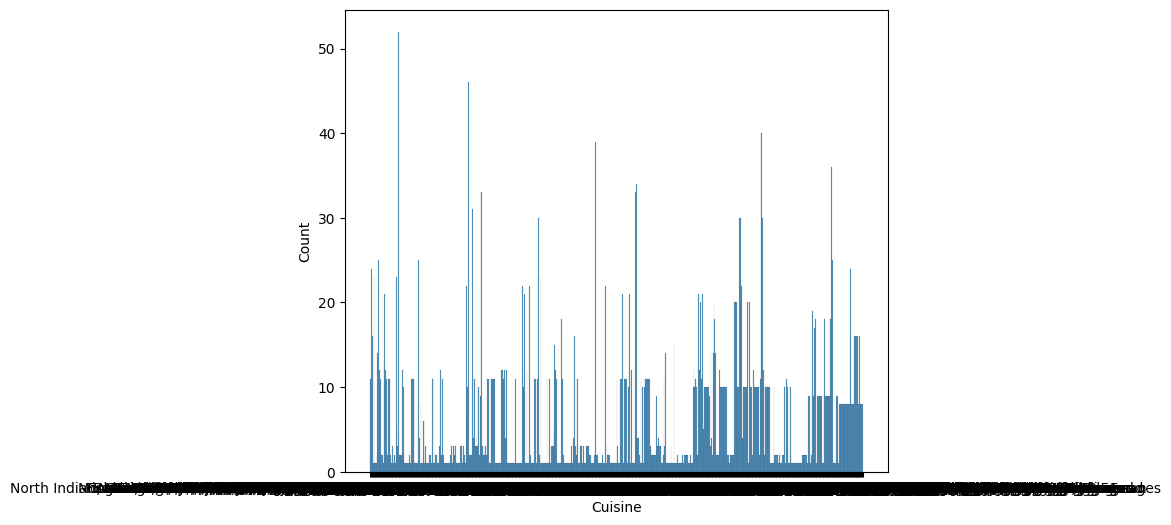

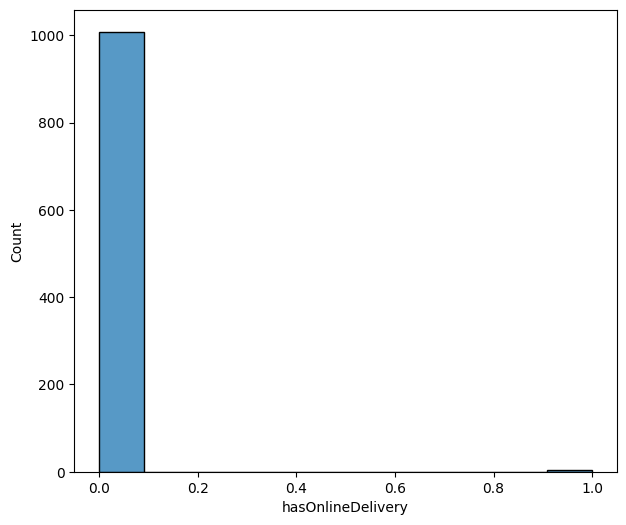

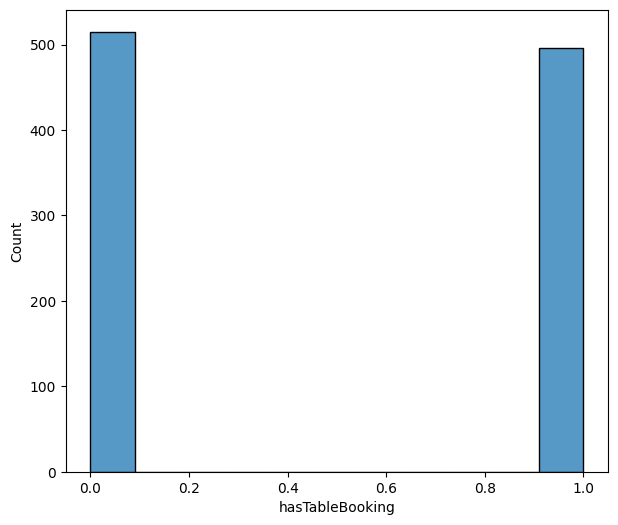

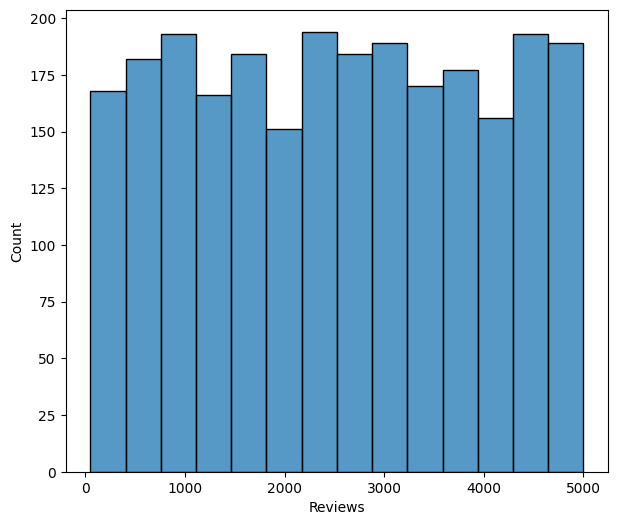

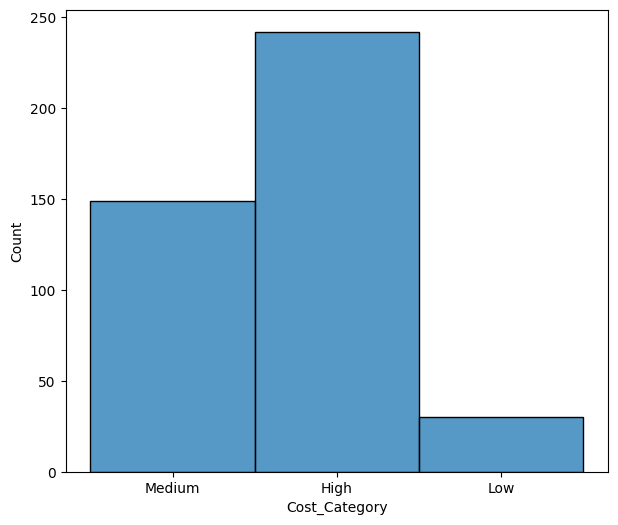

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in ['Cuisine','hasOnlineDelivery','hasTableBooking','Reviews','Cost_Category',]:
  plt.figure(figsize=(7,6))
  sns.histplot(df_new[col])
  plt.show()

In [ ]:
df_new['city_restaurant_count'].value_counts()

,count
city_restaurant_count,
539,539
431,431
420,420
389,389
333,333
314,314
305,305
304,304
299,299


In [ ]:
df_new['Price'].value_counts()

,count
Price,
1000.0,454
1500.0,322
1800.0,312
2500.0,289
2000.0,270
1200.0,262
600.0,167
1600.0,154
1400.0,144


In [ ]:
df_new['Reviews'].value_counts()

,count
Reviews,
4714.0,4
783.0,4
2240.0,4
3159.0,4
2809.0,4
...,...
754.0,1
163.0,1
3366.0,1


outliers checking

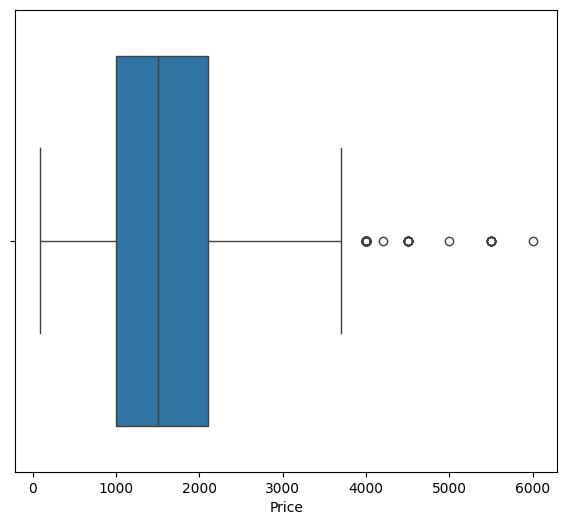

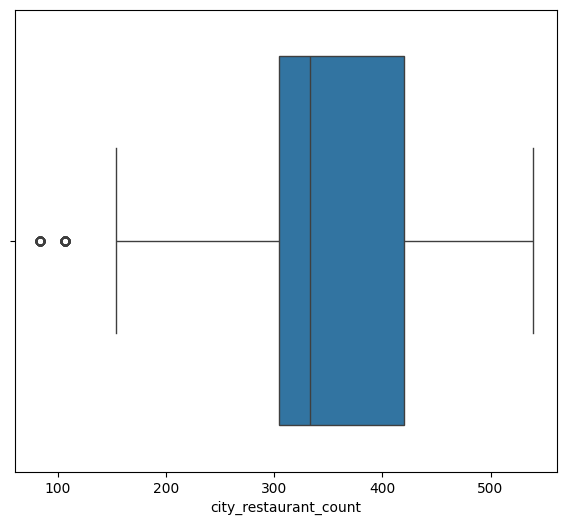

In [ ]:
#outliers checking
for col in ['Price','city_restaurant_count']:
  plt.figure(figsize=(7,6))
  sns.boxplot(x=df_new[col])
  plt.show()

city restaurent count outliers are Rajkot/Patna and Guwahati —  tiny cities. They are genuine data, not errors. The spread from ~150 to ~540 simply reflects real city size differences in  dataset.

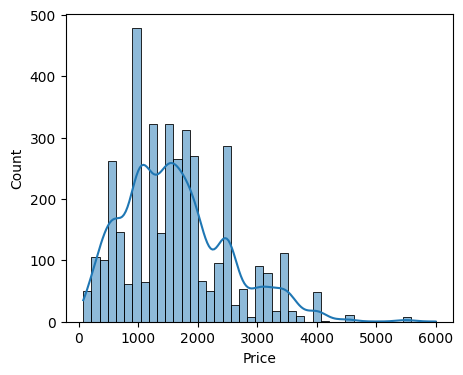

In [ ]:
for col in ['Price']:
  plt.figure(figsize=(5,4))
  sns.histplot(df_new[col],kde=True)
  plt.show()

In [14]:
df_new.shape

(3888, 10)

In [13]:
#capping for price
from pandas.core import series
def cap_outliers(series):
  Q1=series.quantile(0.25)
  Q3=series.quantile(0.75)
  IQR=Q3-Q1
  #BOUND
  lower_bound=Q1-1.5*IQR
  upper_bound=Q3+1.5*IQR
  #CAPPING
  series=np.where(series<lower_bound,lower_bound,series)
  series=np.where(series>upper_bound,upper_bound,series)
  return series

In [15]:
import numpy as np
df_new['Price']=cap_outliers(df_new['Price'])

null values handling

In [16]:
num_col=['hasOnlineDelivery','hasTableBooking','Reviews']
for col in num_col:
  df_new[col]=df_new[col].fillna(df_new[col].median())

In [17]:
cat_col=['Cuisine','Cost_Category']
for col in cat_col:
  df_new[col]=df_new[col].fillna(df_new[col].mode()[0])

In [18]:
df_new.isnull().sum()

,0
Cuisine,0
Price,0
Rating,0
City,0
Area,0
hasOnlineDelivery,0
hasTableBooking,0
Cost_Category,0
Reviews,0
city_restaurant_count,0


# **PREPROCESSING**

PRICE BUCKETS

 Price_bucket and location_tier as pandas Categorical columns (from pd.cut and pd.qcut). When OrdinalEncoder receives these it may throw errors or produce NaN. You need to convert them to plain strings first.

In [ ]:
#divides by value range
# decide the bin boundaries  Like, "anything from 0 to 300 is Budget, 300 to 600 is Mid-range."

In [19]:
df_new['Price_bucket'] = pd.cut(
    df_new['Price'],
    bins  = [0, 300, 600, 1000, float('inf')],
    labels= ['Budget', 'Mid-range', 'Premium', 'Luxury']
).astype(str)

-  one restaurant belongs to many cuisine labels at the same time.
- get_dummies on the whole string "Chinese, Sushi, Asian" — Python treats the entire string as one single category. It will never match another restaurant because no two restaurants have the exact same cuisine combination written the same way.
- creates one column per cuisine. Then puts a 1 if the restaurant has that cuisine, 0 if not.

In [20]:
from sklearn.preprocessing import MultiLabelBinarizer

df_new['Cuisine_list'] = df_new['Cuisine'].str.split(',').apply(
    lambda x: [i.strip() for i in x]
)
top5 = (df_new['Cuisine_list'].explode()
        .value_counts().nlargest(5).index.tolist())
df_new['Cuisine_list'] = df_new['Cuisine_list'].apply(
    lambda lst: [c if c in top5 else 'Other' for c in lst]
)
mlb = MultiLabelBinarizer()
cuisine_dummies = pd.DataFrame(
    mlb.fit_transform(df_new['Cuisine_list']),
    columns=[f'Cuisine_{c}' for c in mlb.classes_],
    index=df_new.index
)
df_new = pd.concat([df_new, cuisine_dummies], axis=1)
df_new.drop(columns=['Cuisine', 'Cuisine_list'], inplace=True)
print(f'Shape after cuisine encoding: {df_new.shape}')

Shape after cuisine encoding: (3888, 16)


In [21]:
df_new

,Price,Rating,City,Area,hasOnlineDelivery,hasTableBooking,Cost_Category,Reviews,city_restaurant_count,Price_bucket,Cuisine_Beverages,Cuisine_Chinese,Cuisine_Continental,Cuisine_Desserts,Cuisine_North Indian,Cuisine_Other
0,1800.0,4.3,bangalore,indiranagar,0.0,1.0,High,2540.0,431,Luxury,0,0,1,0,0,1
1,2000.0,4.6,bangalore,indiranagar,0.0,1.0,High,2540.0,431,Luxury,0,0,0,0,0,1
2,2500.0,4.2,bangalore,indiranagar,0.0,1.0,High,2540.0,431,Luxury,1,0,1,1,0,1
3,1200.0,4.5,bangalore,indiranagar,0.0,0.0,High,2540.0,431,Luxury,1,0,0,1,0,1
4,2600.0,4.6,bangalore,indiranagar,0.0,1.0,High,2540.0,431,Luxury,0,0,0,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3883,1000.0,4.4,pune,kothrud,0.0,0.0,High,1535.0,305,Premium,0,0,1,0,0,1
3884,2000.0,4.8,pune,kothrud,0.0,0.0,High,4025.0,305,Luxury,0,1,1,0,1,1
3885,1800.0,4.3,pune,kothrud,0.0,0.0,High,1058.0,305,Luxury,0,0,1,1,0,1
3886,1000.0,4.1,pune,kothrud,0.0,0.0,High,1787.0,305,Premium,1,1,1,1,1,1


In [22]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder


x = df_new.drop('Rating', axis=1)
y = df_new['Rating']

In [23]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

location tiers

In [24]:

#  create count from training only
city_count_map = x_train['City'].value_counts()

x_train['city_restaurant_count'] = x_train['City'].map(city_count_map)
x_test['city_restaurant_count'] = x_test['City'].map(city_count_map)

# create tier based on training only
x_train['location_tier'] = pd.qcut(
    x_train['city_restaurant_count'],
    q=3,
    labels=['Low_activity', 'Medium_activity', 'High_activity']
)

# Apply same bins to test
bins = pd.qcut(x_train['city_restaurant_count'], q=3, retbins=True)[1]

x_test['location_tier'] = pd.cut(
    x_test['city_restaurant_count'],
    bins=bins,
    labels=['Low_activity', 'Medium_activity', 'High_activity'],
    include_lowest=True
)

- StandardScaler  → numerical columns (Price, Reviews, city_restaurant_count)
  Reason: these have different scales, scaling puts them on equal footing

- OrdinalEncoder  → Price_bucket, location_tier
  Reason: these have a natural order (Budget < Premium, Low < High)
  so ordinal encoding preserves that meaning

- OneHotEncoder   → City, Area, Cost_Category
  Reason: no natural order between cities/areas,
  one-hot creates separate binary column for each value



In [25]:
num_col = ['Price', 'hasOnlineDelivery', 'hasTableBooking', 'Reviews', 'city_restaurant_count']
nom_col = ['City', 'Area', 'Cost_Category']
ord_col = ['Price_bucket', 'location_tier']

price_order = ['Budget', 'Mid-range', 'Premium', 'Luxury']
tier_order = ['Low_activity', 'Medium_activity', 'High_activity']


preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_col),
        ('ord', OrdinalEncoder(categories=[price_order, tier_order]), ord_col),
        ('nom', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), nom_col)
    ],
    remainder='passthrough',
    force_int_remainder_cols=False
)


“I ensure forward compatibility by using parameters like force_int_remainder_cols=False to align with future sklearn updat

 any column NOT listed in num_col, ord_col, or nom_col is passed through unchanged.

###**RandomForestRegressor**

In [26]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        random_state=42
    ))
])

pipe.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['Price', 'hasOnlineDelivery',
                                                   'hasTableBooking', 'Reviews',
                                                   'city_restaurant_count']),
                                                 ('ord',
                                                  OrdinalEncoder(categories=[['Budget',
                                                                              'Mid-range',
                                                                              'Premium',
                                                                              'Luxury'],
                                                                             ['Low_activity',
                                                                              'Medium_activity',
                                                                              'High_activity']]),
                                                  ['Price_bucket',
                                                   'location_tier']),
                                                 ('nom',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['City', 'Area',
                                                   'Cost_Category'])])),
                ('model',
                 RandomForestRegressor(max_depth=10, n_estimators=200,
                                       random_state=42))])

In [27]:
#prediction
y_pred=pipe.predict(x_test)
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

y_pred = pipe.predict(x_test)

print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))


R2: 0.7036655358350117
MAE: 0.11837695299499407
RMSE: 0.17594711167445756


###**DecisionTreeRegressor**

In [28]:
from sklearn.tree import DecisionTreeRegressor
pipe_dt=Pipeline([
    ('preprocessor',preprocessor),
    ('model',DecisionTreeRegressor())
])
pipe_dt.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['Price', 'hasOnlineDelivery',
                                                   'hasTableBooking', 'Reviews',
                                                   'city_restaurant_count']),
                                                 ('ord',
                                                  OrdinalEncoder(categories=[['Budget',
                                                                              'Mid-range',
                                                                              'Premium',
                                                                              'Luxury'],
                                                                             ['Low_activity',
                                                                              'Medium_activity',
                                                                              'High_activity']]),
                                                  ['Price_bucket',
                                                   'location_tier']),
                                                 ('nom',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['City', 'Area',
                                                   'Cost_Category'])])),
                ('model', DecisionTreeRegressor())])

In [29]:
y_pred = pipe_dt.predict(x_test)

print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2: 0.6924526878488353
MAE: 0.05705869751499594
RMSE: 0.17924499095070895


###**XGBRegressor**

In [43]:
from xgboost import XGBRegressor

pipe_xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ))
])

pipe_xgb.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['Price', 'hasOnlineDelivery',
                                                   'hasTableBooking', 'Reviews',
                                                   'city_restaurant_count']),
                                                 ('ord',
                                                  OrdinalEncoder(categories=[['Budget',
                                                                              'Mid-range',
                                                                              'Premium',
                                                                              'Luxury'],
                                                                             ['Low_activity',
                                                                              'Medium_activity',
                                                                              'High_activity...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=6, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=300, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [44]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

y_pred = pipe_xgb.predict(x_test)

print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2: 0.7482120031800998
MAE: 0.10275845919905713
RMSE: 0.1621842106594259


In [45]:
from sklearn.model_selection  import RandomizedSearchCV

param_grid ={
    'model__n_estimators': [200, 300, 500],
    'model__learning_rate': [0.01, 0.03, 0.05, 0.1],
    'model__max_depth': [4, 6, 8],
    'model__subsample': [0.7, 0.8, 1.0],
    'model__colsample_bytree': [0.7, 0.8, 1.0],
    'model__reg_alpha': [0, 0.1, 1],
    'model__reg_lambda': [1, 2, 5]
}



search=RandomizedSearchCV(
    pipe_xgb,
    param_distributions=param_grid,
    cv=5,
    scoring='r2',
    verbose=2,
    n_jobs=-1
)
search.fit(x_train,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(force_int_remainder_cols=False,
                                                                remainder='passthrough',
                                                                transformers=[('num',
                                                                               StandardScaler(),
                                                                               ['Price',
                                                                                'hasOnlineDelivery',
                                                                                'hasTableBooking',
                                                                                'Reviews',
                                                                                'city_restaurant_count']),
                                                                              ('ord',
                                                                               OrdinalEncoder(categories=[['Budget',
                                                                                                           'Mid-range',
                                                                                                           'Premium',
                                                                                                           'Luxury'],
                                                                                                          ['Low_activity...
                                                           n_estimators=300,
                                                           n_jobs=None,
                                                           num_parallel_tree=None, ...))]),
                   n_jobs=-1,
                   param_distributions={'model__colsample_bytree': [0.7, 0.8,
                                                                    1.0],
                                        'model__learning_rate': [0.01, 0.03,
                                                                 0.05, 0.1],
                                        'model__max_depth': [4, 6, 8],
                                        'model__n_estimators': [200, 300, 500],
                                        'model__reg_alpha': [0, 0.1, 1],
                                        'model__reg_lambda': [1, 2, 5],
                                        'model__subsample': [0.7, 0.8, 1.0]},
                   scoring='r2', verbose=2)

In [46]:
search.best_params_

{'model__subsample': 0.7,
 'model__reg_lambda': 1,
 'model__reg_alpha': 0,
 'model__n_estimators': 500,
 'model__max_depth': 8,
 'model__learning_rate': 0.1,
 'model__colsample_bytree': 1.0}

In [47]:
search.best_score_

np.float64(0.7911943952481651)

In [48]:
best_model=search.best_estimator_
y_pred_tuned=best_model.predict(x_test)

In [49]:
print("R2:", r2_score(y_test, y_pred_tuned))
print("MAE:", mean_absolute_error(y_test, y_pred_tuned))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_tuned)))

R2: 0.7854203459982094
MAE: 0.06867511817912518
RMSE: 0.1497219002455815


In [50]:
print(f'befor tuning={r2_score(y_test, y_pred)}')
print(f'after tuning={r2_score(y_test, y_pred_tuned)}')

befor tuning=0.7482120031800998
after tuning=0.7854203459982094



###**Interpretations**

- r2 score - model explains 80% variation in restaurent rating
- MAE- on average prediction, prediction are off only  by 0.07 rating points
- RMSE- models typical prediction errors around 0.14,slightly penalizing larger errors.

###**Feature importance**

In [51]:
#How much each input (feature) affects the final prediction
import pandas as pd

importance=pipe_xgb.named_steps['model'].feature_importances_
features=pipe_xgb.named_steps['preprocessor'].get_feature_names_out()

feat_imp= pd.DataFrame({
    'feature':features,
    'importance':importance

}).sort_values(by='importance',ascending=False)
print(feat_imp.head(15))

                    feature  importance
14      nom__City_mangalore    0.054080
18         nom__City_trichy    0.050188
59      nom__Area_surathkal    0.045509
62  nom__Area_thillai-nagar    0.041895
70       nom__Area_woraiyur    0.039878
7       nom__City_ahmedabad    0.038932
66      nom__Area_velachery    0.031207
5         ord__Price_bucket    0.027725
9         nom__City_chennai    0.027190
41   nom__Area_kuvempunagar    0.026274
33          nom__Area_kadri    0.023935
16         nom__City_mysore    0.023240
10     nom__City_coimbatore    0.021640
34       nom__Area_kakkanad    0.020808
39    nom__Area_koramangala    0.020633


Some cities have better food culture
Some areas have more competition
Some places have higher expectations, So ratings vary by location.
- The model shows that location-based features such as city and area have a strong influence on restaurant ratings, indicating that geographic factors play an important role in customer perception  significantly impact ratings, possibly due to varying customer expectations and competition levels.The model is using location (city/area) as an important factor to predict ratings.”

###**Actual vs predicted**

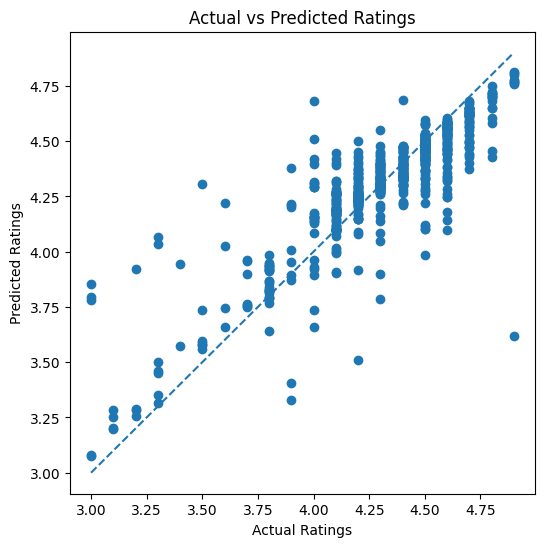

In [52]:
import matplotlib.pyplot as plt
y_pred=pipe_xgb.predict(x_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test,y_pred)

plt.xlabel('Actual Ratings')
plt.ylabel('Predicted Ratings')
plt.title('Actual vs Predicted Ratings')

plt.plot([y_test.min(),y_test.max()],
         [y_test.min(),y_test.max()],
         linestyle='--')
plt.show()

The scatter plot shows that most predicted ratings lie close to the diagonal line, indicating strong agreement between actual and predicted values. This confirms that the model is accurately capturing rating patterns.

In [54]:
import pickle
with open ('Best_model_pkl','wb') as f:
  pickle.dump(best_model,f)